# DHS Data Cleaning and Target Engineering

This notebook serves as the primary pipeline for processing raw Demographic and Health Survey (DHS) data. To ensure architectural consistency, we utilize the project-wide constants.py for path management and categorical mapping. 

Our objective is to transform raw survey responses into a model-ready dataset for individual dropout prediction.

## Data Loading

We ingest the filtered DHS individual features. This dataset contains 32,156 records reflecting demographics, testing history, and healthcare access indicators across Kenya's 47 counties.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Aligning with project structure: notebooks/ -> root/constants.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import constants as c

# Print paths for stakeholder verification
print(f"Data Source: {c.DHS_REDUCED}")
print(f"Data Destination: {c.DHS_CLEAN}")

Data Source: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/raw/individual_features.csv
Data Destination: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/individual_features_clean.csv


In [4]:
# Load the raw individual feature set
df = pd.read_csv(c.DHS_REDUCED)

# Display initial schema and head for validation
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   case_id                   32156 non-null  object 
 1   county                    32156 non-null  int64  
 2   age_group                 32156 non-null  int64  
 3   education_level           32156 non-null  int64  
 4   wealth_index              32156 non-null  int64  
 5   worked_last_12months      32156 non-null  int64  
 6   ever_tested_hiv           16901 non-null  float64
 7   tested_hiv_last_12months  13815 non-null  float64
 8   distance_to_facility      13815 non-null  float64
 9   marital_status            32156 non-null  int64  
 10  currently_in_union        32156 non-null  int64  
 11  num_sexual_partners       16900 non-null  float64
 12  knows_aids_death          0 non-null      float64
 13  told_hiv_positive         16901 non-null  float64
 14  has_he

,case_id,county,age_group,education_level,wealth_index,worked_last_12months,ever_tested_hiv,tested_hiv_last_12months,distance_to_facility,marital_status,currently_in_union,num_sexual_partners,knows_aids_death,told_hiv_positive,has_health_insurance
0,1 4 2,1,4,0,4,0,1.0,1.0,10.0,1,1,0.0,NaN,0.0,NaN
1,1 7 2,1,5,2,5,1,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN
2,1 10 1,1,4,1,5,2,1.0,1.0,6.0,4,2,1.0,NaN,0.0,NaN
3,1 13 2,1,5,2,5,2,1.0,1.0,5.0,1,1,1.0,NaN,0.0,NaN
4,1 20 2,1,4,1,4,2,1.0,1.0,68.0,2,1,1.0,NaN,0.0,NaN


## Assessing Baseline Data Quality

Transparency regarding data gaps is critical for stakeholder trust. We visualize the missing value distribution in the raw data to justify our subsequent imputation strategies.

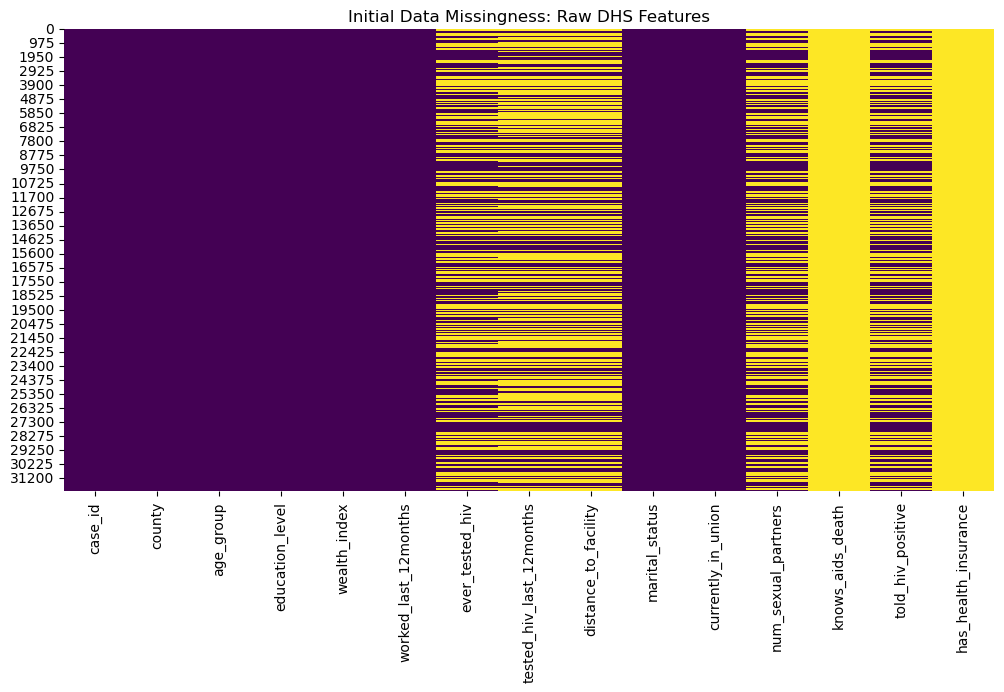

In [6]:
# Generate 'Before' Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Initial Data Missingness: Raw DHS Features")
plt.savefig("../figures/dhs_missing_before.png")
plt.show()

## Feature Decoding and Normalization

To facilitate interpretability and downstream analysis, we translate raw survey codes (integers) into descriptive labels. This involves mapping county identifiers to names and decoding demographic variables such as education and wealth status using established DHS standards.

In [7]:
# Decoding numeric codes using constants.py maps
df["county"] = df["county"].map(c.DHS_COUNTY_MAP)
df["age_group"] = df["age_group"].map(c.DHS_AGE_GROUP_MAP)
df["education_level"] = df["education_level"].map(c.DHS_EDUCATION_MAP)
df["wealth_index"] = df["wealth_index"].map(c.DHS_WEALTH_MAP)
df["marital_status"] = df["marital_status"].map(c.DHS_MARITAL_MAP)
df["distance_to_facility"] = df["distance_to_facility"].map(c.DHS_DISTANCE_MAP)

# Verify decoding success
df[["county", "education_level", "wealth_index"]].head()

,county,education_level,wealth_index
0,Mombasa,No education,Richer
1,Mombasa,Secondary,Richest
2,Mombasa,Primary,Richest
3,Mombasa,Secondary,Richest
4,Mombasa,Primary,Richer


## Data Imputation Strategy

To maintain the predictive power of the dataset, we address missing values using a two-pronged approach:

   - **Binary Features:** Omitted values in testing and insurance flags are treated as "No" (0).

   - **Numeric Features:** Continuous variables like sexual partners or facility visits are imputed with the median to mitigate the influence of outliers.

In [9]:
# Impute binary health and testing flags with 0
binary_cols = [
    "ever_tested_hiv",
    "tested_hiv_last_12months",
    "told_hiv_positive",
    "has_health_insurance",
]
df[binary_cols] = df[binary_cols].fillna(0)

# Impute numeric features with median (e.g., sexual partners, anc_visits)
numeric_to_impute = ["num_sexual_partners", "anc_visits"]
for col in numeric_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

## Engineering the Dropout Predictor

The primary target variable for our AI model is the **Care Gap Dropout**. We define a "*Dropout*" as an individual who has been informed they are HIV positive but has not sought testing or follow-up services within the last 12 months. This allows the model to focus specifically on the gap between diagnosis and ongoing care.

In [10]:
# Target: 1 if HIV+ and not tested in last 12m, else 0
df["dropout"] = (
    (df["told_hiv_positive"] == 1) & (df["tested_hiv_last_12months"] == 0)
).astype(int)

# Report class ratio for the modeling team
print("Calculated Class Ratio for Modeling (Dropout vs Retained):")
print(df["dropout"].value_counts(normalize=True))

Calculated Class Ratio for Modeling (Dropout vs Retained):
dropout
0    0.999191
1    0.000809
Name: proportion, dtype: float64
